## Handling missing data 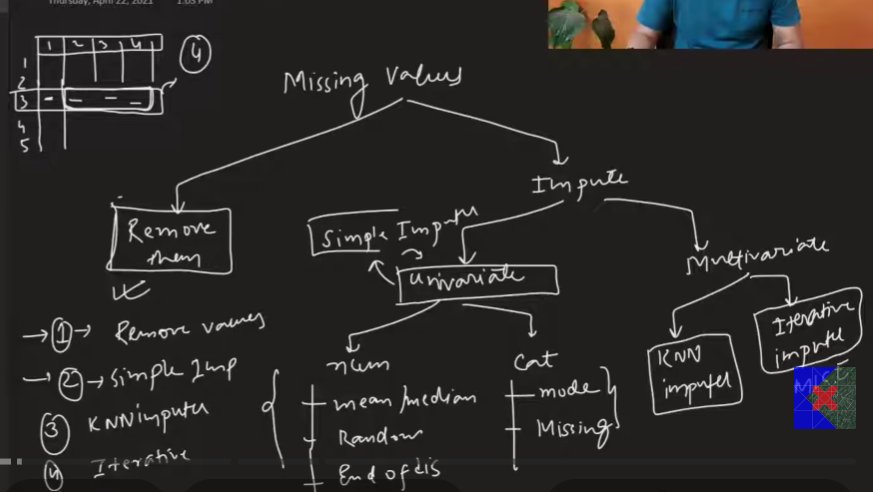

> 1) `Removing Values`: also called `Complete Case Analysis`.
another name-"`List wise deletion`.consists in idscarding observations where values in any of the variables are missing.

CCA means literally analyzing only those obseravtions for which there is information in all of the variables in the dataset.



> Assumptions for CCA:
The missing data shhould be at Random. it should not be continuous.

> Advantages & Disadvantages of CCA:
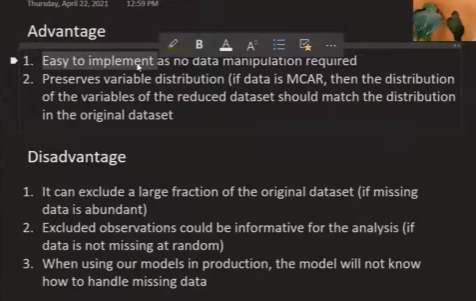


> When to use CCA?

1. when there is MCAR (missing data at random)
2. CCA can only be applied when any columne has `less than 5% of missing data`. we should not apply CCA if missing data percentage is greater tha 5%.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv("data_science_job.csv")

In [ ]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [ ]:
df.isnull().mean() *100


,0
enrollee_id,0.000000
city,0.000000
city_development_index,2.500261
gender,23.530640
relevent_experience,0.000000
enrolled_university,2.014824
education_level,2.401086
major_discipline,14.683161
experience,0.339284
company_size,30.994885


#### We can only apply CCA on cols `enrolled_university`,`education_level`,`training_hours`.`city_development_index`.`experience`

In [ ]:
df.shape

(19158, 13)

In [ ]:
cols = [var for var in df.columns if df[var].isnull().mean() <0.05 and df[var].isnull().mean()>0]

cols  #cols with missing data > 0 and less than 5%

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [ ]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
5420,0.926,no_enrollment,Masters,10.0,50.0
12305,0.910,no_enrollment,High School,0.0,39.0
8137,0.897,no_enrollment,Graduate,20.0,21.0
12817,0.624,no_enrollment,High School,2.0,104.0
7011,0.926,no_enrollment,Graduate,6.0,26.0


In [ ]:
df['education_level'].value_counts()   #categorical data

,count
education_level,
Graduate,11598
Masters,4361
High School,2017
Phd,414
Primary School,308


In [ ]:
len(df[cols].dropna())/ len(df)

0.8968577095730244

In [ ]:
new_df = df[cols].dropna()
df.shape, new_df.shape

((19158, 13), (17182, 5))

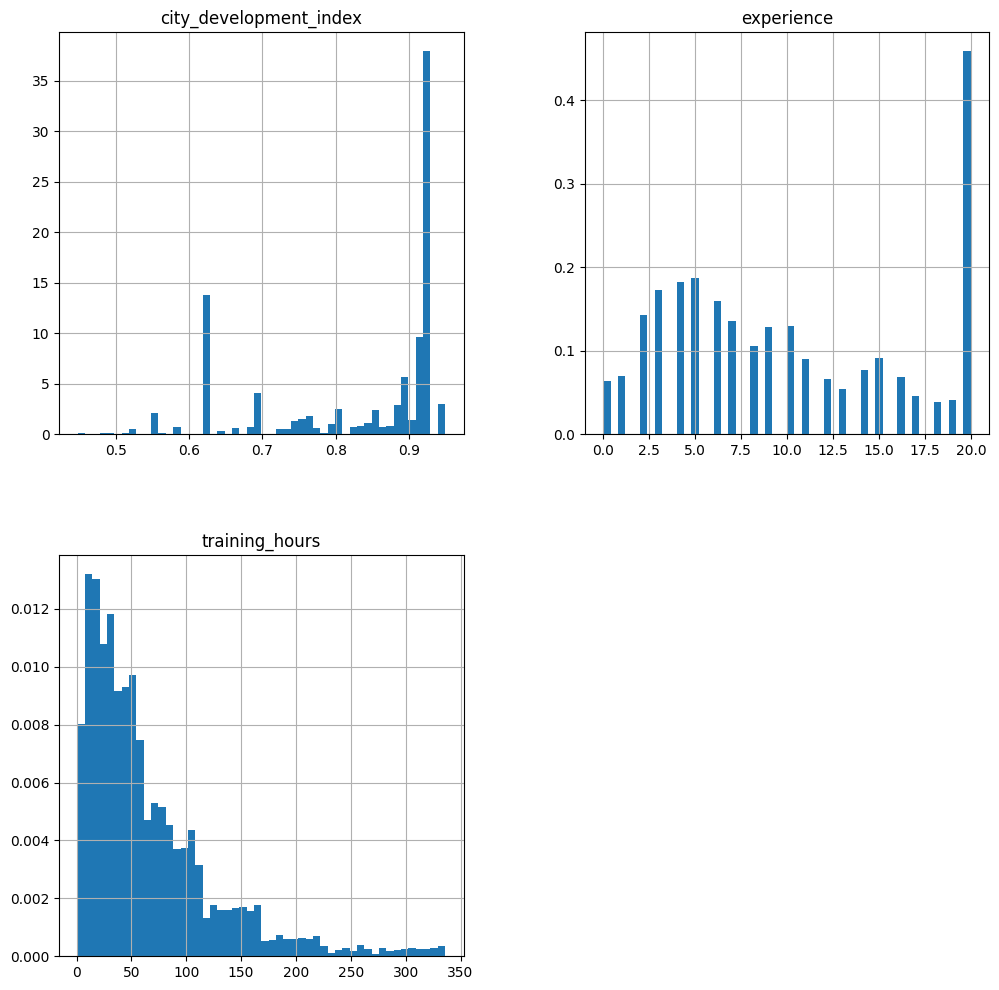

In [ ]:
new_df.hist( bins=50 ,density =True, figsize=(12,12))
plt.show() # this is the histogram for new columns made afte removing missing values

## data before and after CCA-

* we are seeing a mix of grren and red color since they are overlapping one another.


<Axes: >

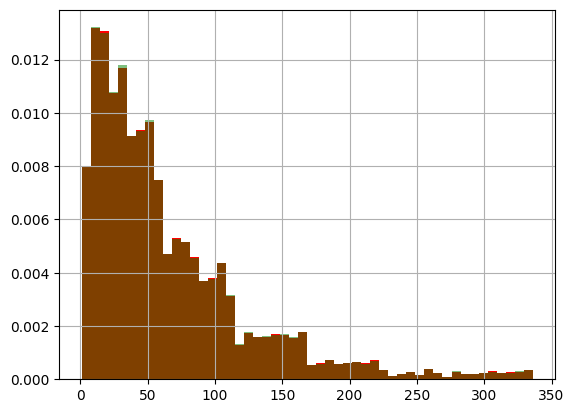

In [ ]:
fig= plt.figure()
ax= fig.add_subplot (111)

#original data
df['training_hours'].hist (bins=50, ax=ax, density=True, color='red')


#data after CCA, the argumnet akpha makes the color transparent so we can see the
# overlay of two distributions
new_df['training_hours'].hist (bins=50, ax=ax, density=True, color='green', alpha=0.5)



# we are seeing a mix of grren and red color since they are overlapping one
#another.


### `training_hours` before and after CCA:

<Axes: ylabel='Density'>

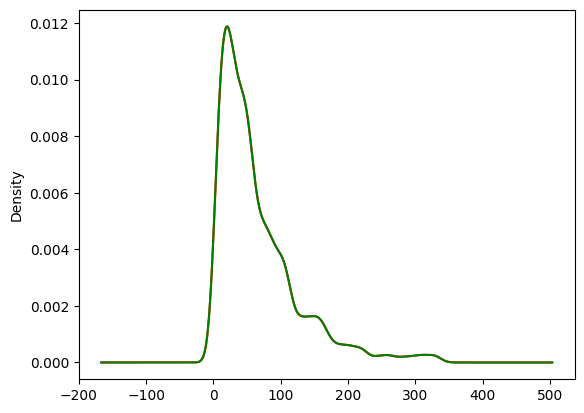

In [ ]:
fig= plt.figure()
ax=fig.add_subplot(111)

#original data
df['training_hours'].plot.density(color='red')

#data after CCA
df['training_hours'].plot.density(color="green")

### city_development_index` before and after CCA:

<Axes: >

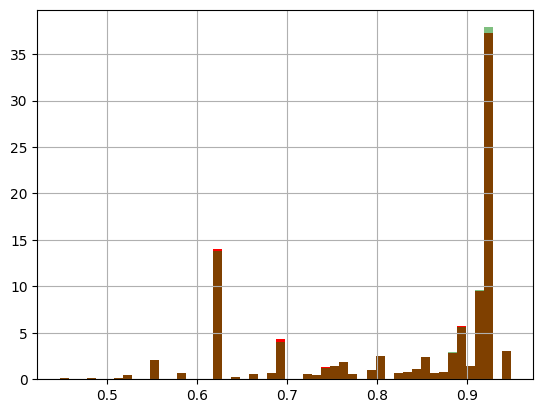

In [ ]:
fig= plt.figure()
ax= fig.add_subplot (111)

#original data
df['city_development_index'].hist (bins=50, ax=ax, density=True, color='red')


#data after CCA, the argumnet akpha makes the color transparent so we can see the
# overlay of two distributions
new_df['city_development_index'].hist (bins=50, ax=ax, density=True, color='green', alpha=0.5)

### `experience` before and after CCA:

<Axes: ylabel='Density'>

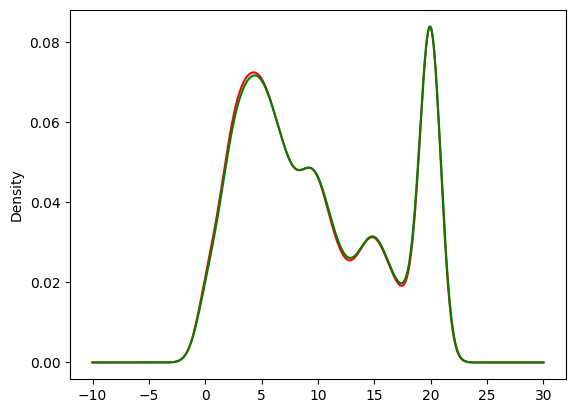

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['experience'].plot.density(color='red')

# data after cca
new_df['experience'].plot.density(color='green')

# Comparison Table (before VS after CCA) for `enrolled_university`


In [ ]:
temp = pd.concat([
            # percentage of observations per category, original data
            df['enrolled_university'].value_counts() / len(df),

            # percentage of observations per category, cca data
            new_df['enrolled_university'].value_counts() / len(new_df)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']

temp


,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


### the percentages are almost similar

# Comparison Table (before VS after CCA) for `education_level`

In [ ]:
temp = pd.concat([
            # percentage of observations per category, original data
            df['education_level'].value_counts() / len(df),

            # percentage of observations per category, cca data
            new_df['education_level'].value_counts() / len(new_df)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']

temp


,original,cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
